In [330]:
import time
import json
import os
import sys
import math
sys.path.append(os.path.dirname(os.getcwd()))
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import Normalize
from PIL import Image

from pc import PS
from modules import ADC,DAC,CHIP,COMPENSATION_PARA
from command import CMD,CmdData,Packet
from command.singleCmdInfo import *

from util import *

from network.layer import Layer

from scipy.stats import norm
from scipy.optimize import curve_fit

In [331]:
chip=CHIP(PS(host="192.168.1.11", port = 7, debug=0),init=True)
# deviceType参数：0为ReRAM，1为ECRAM
# IsNew32参数：False为v1版本，True为v2版本
chip.set_device_cfg(deviceType=0,IsNew32=True)
chip.adc.set_gap(adc_cs_gap=90,adc_first_gap=20,adc_last_gap=10)
chip.adc.set_gain_resistor(big_resistance=10e3,small_resistance=200)
chip.clk_manager.set_cyc(10, 10,delay3=50)
chip.add_compiler("../compiler/code/")
chip.compensation.initop("../chip_data/chip6_/pcb_203/")

Connected to 192.168.1.11:7
local ip: 192.168.1.15 local port: 55151
正在编译文件:  ../compiler/code/read_point3_from_col.txt
正在编译文件:  ../compiler/code/read_point3_from_row.txt
正在编译文件:  ../compiler/code/row_read_point3.txt
正在编译文件:  ../compiler/code/set_reset.txt
正在编译文件:  ../compiler/code/write_verify.txt
指令set_dac未实现
指令set_dac未实现
正在编译文件:  ../compiler/code/汇编测试代码.txt
正在编译文件:  ../compiler/code/读任意大小的块-汇编代码示例.txt
正在编译文件:  ../compiler/code/读单点测试.txt


In [332]:
root_path = "../chip_data/chip6_/pcb_202/"

# 1. 准备数据

In [ ]:
v,c_expected_from_row,r = chip.read4(crossbar=np.ones((256,256)),row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=True,split_type=0,row_type=0,col_type=0)
c_expected_from_row = chip.compensation.compensation_point(r,from_row=True,return_type=0)

v,c_expected_from_col,r = chip.read4(crossbar=np.ones((256,256)),row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=False,split_type=0,row_type=0,col_type=0)
c_expected_from_col = chip.compensation.compensation_point(r,from_row=False,return_type=0)

## 1.0 计算R_out

In [ ]:
crossbar = np.ones((256,256))
v,c,r = chip.read4(crossbar=crossbar,row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=True,split_type=0,row_type=0,col_type=0)
plot_cond(c,vmax=1000)

In [ ]:
# 注意！！！执行前一定要改名字
compensation = COMPENSATION_PARA()
filename = root_path + "col_r_out_base.npy"
point_read,sum_read = compensation.calculate_r_out_from_r_wire(chip=chip,num=30,from_row=True)
r_out_col = compensation.get_r_out(point_read=point_read,sum_read=sum_read,filename=filename,from_row=True)

In [ ]:
tmp = r_out_col.copy()
for i,v in enumerate(r_out_col):
    if v>25:
        tmp[i]=(tmp[i-1]+tmp[i+1])/2

filename = root_path + "col_r_out.npy"
np.save(filename,tmp)
plt.plot(tmp)
plt.xlabel("col")
plt.ylabel("Ω")
plt.show()

In [ ]:
filename = root_path + "row_r_out_base.npy"
point_read,sum_read = compensation.calculate_r_out_from_r_wire(chip=chip,num=30,from_row=False)
r_out_row = compensation.get_r_out(point_read=point_read,sum_read=sum_read,filename=filename,from_row=False)

In [ ]:
tmp = r_out_row.copy()
for i,v in enumerate(r_out_row):
    if v>25:
        tmp[i]=(tmp[i-1]+tmp[i+1])/2

filename = root_path + "row_r_out.npy"
np.save(filename,tmp)
plt.plot(tmp)
plt.show()
print(r_out_row)

In [ ]:
col_r_out = np.load(root_path + "col_r_out.npy")
plt.plot(col_r_out)
plt.show()

row_r_out = np.load(root_path + "row_r_out.npy")
plt.plot(row_r_out)
plt.show()

## 1.1 从行给信号

In [ ]:
chip.compensation.initop(root_path)
# 10列，两路TIA并行
col_index = [i for i in range(256)]
# 存储数据
real_res = np.zeros((256,256))
real_cond_res = np.zeros((256,256))
expected_res = np.zeros((256,256))

for i in range(101):
    row_index = [j for j in range(i+1)]

    _,cond,r = chip.read4(crossbar=np.ones((256,256)),row_index=row_index,col_index=col_index,read_voltage=0.1,tg=5,gain=3,sub_base=True,from_row=True,split_type=3,row_type=0,col_type=0)
    cond = chip.compensation.compensation_forward(row_index,r,from_row=True,return_type=0,parallel=0)
    pos = np.ix_(row_index,col_index)
    expected_res[i,:]=np.sum(c_expected_from_row[pos],axis=0)
    real_res[i,:]=r
    real_cond_res[i,:] = cond[col_index]

In [ ]:
startpos,endpos = 0,101
for num in range(10):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(real_cond_res[startpos:endpos,num].flatten(),label = "actual output")
    plt.plot(expected_res[startpos:endpos,num].flatten(),label = "expected output")
    plt.title(f"col={col_index[num]}")
    plt.ylabel("uS")
    plt.xlabel("row nums")
    plt.legend()
    # plt.show()
    plt.subplot(1,2,2)
    plt.plot(real_cond_res[startpos:endpos,num].flatten()/expected_res[startpos:endpos,num].flatten(),label = "actual output/expected output")
    plt.plot(np.ones(endpos-startpos-1),label = "expected output/expected output")
    plt.title(f"col={col_index[num]}")
    plt.ylabel("*100%")
    plt.xlabel("row nums")
    plt.legend()
    plt.show()

In [ ]:
chip.compensation.initop(root_path)
# 10列，两路TIA并行
col_index = [i for i in range(256)]
# 存储数据
real_res = np.zeros((256,256))
real_cond_res = np.zeros((256,256))
expected_res = np.zeros((256,256))

for i in range(101):
    row_index = [j for j in range(i+1)]

    _,cond,r = chip.read4(crossbar=np.ones((256,256)),row_index=row_index,col_index=col_index,read_voltage=0.1,tg=5,gain=3,sub_base=True,from_row=True,split_type=4,row_type=0,col_type=0)
    cond = chip.compensation.compensation_forward(row_index,r,from_row=True,return_type=0,parallel=16)
    pos = np.ix_(row_index,col_index)
    expected_res[i,:]=np.sum(c_expected_from_row[pos],axis=0)
    real_res[i,:]=r
    real_cond_res[i,:] = cond[col_index]

In [ ]:
startpos,endpos = 0,101
for num in range(10):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(real_cond_res[startpos:endpos,num].flatten(),label = "actual output")
    plt.plot(expected_res[startpos:endpos,num].flatten(),label = "expected output")
    plt.title(f"col={col_index[num]}")
    plt.ylabel("uS")
    plt.xlabel("row nums")
    plt.legend()
    # plt.show()
    plt.subplot(1,2,2)
    plt.plot(real_cond_res[startpos:endpos,num].flatten()/expected_res[startpos:endpos,num].flatten(),label = "actual output/expected output")
    plt.plot(np.ones(endpos-startpos-1),label = "expected output/expected output")
    plt.title(f"col={col_index[num]}")
    plt.ylabel("*100%")
    plt.xlabel("row nums")
    plt.legend()
    plt.show()

## 1.2 从列给信号

In [ ]:
chip.compensation.initop(root_path)
chip.compensation.row_offset=0
chip.compensation.row_value=None
# chip.compensation.row_r_out=0
# 10列，两路TIA并行
row_index = [0]
# 存储数据
expected_res = np.zeros((200,100))
real_cond_res = np.zeros((200,100))


for k in range(100):
    for i in range(100):
        col_index = [j for j in range(i+1)]
        _,cond,r = chip.read4(crossbar=np.ones((256,256)),row_index=row_index,col_index=col_index,read_voltage=0.04,tg=5,gain=3,sub_base=True,from_row=False,split_type=3,row_type=0,col_type=0)
        pos = np.ix_(row_index,col_index)
        expected_res[k,i]=np.sum(c_expected_from_col[pos])
        real_cond_res[k,i] = cond[row_index[0]] 

In [ ]:
row_mean = np.mean(real_cond_res, axis=0)
startpos,endpos = 0,100
plt.figure(figsize=(6,4))
for i in range(10):
    plt.plot(real_cond_res[i,startpos:endpos].flatten()/row_mean-1,label = "actual output")
# plt.plot(expected_res[startpos:endpos,num].flatten(),label = "expected output")
# plt.title(f"row={row_index[num]}")
# plt.ylabel("uS")
plt.xlabel("row nums")
# plt.legend()
plt.show()

In [327]:
chip.compensation.initop(root_path)
# chip.compensation.row_offset=0
# chip.compensation.row_value=None
# chip.compensation.row_r_out=0
# 10列，两路TIA并行
row_index = [i for i in range(256)]
# 存储数据
real_res = np.zeros((256,256))
real_cond_res = np.zeros((256,256))
expected_res = np.zeros((256,256))
for i in range(101):
    col_index = [j for j in range(i+1)]

    _,cond,r = chip.read4(crossbar=np.ones((256,256)),row_index=row_index,col_index=col_index,read_voltage=0.1,tg=5,gain=3,sub_base=True,from_row=False,split_type=3,row_type=0,col_type=0)
    cond = chip.compensation.compensation_forward(col_index,r,from_row=False,return_type=0)
    pos = np.ix_(row_index,col_index)
    expected_res[i,:]=np.sum(c_expected_from_col[pos],axis=1).flatten()
    real_res[i,:]=r
    real_cond_res[i,:] = cond[row_index]

In [328]:
def compensation_value_from_col(x,mult,row):
    """
        计算补偿
    """
    rows = len(x)
    return real_cond_res[:rows,row]/expected_res[:rows,row]*mult

cnt = 101
ans = np.zeros(256)
for i in range(256):
    params, covariance = curve_fit(lambda x,value:compensation_value_from_col(x,value,i),[i for i in range(cnt)], np.ones(cnt), p0=[0.5],bounds=([0], [1]))
    ans[i] = params[0]

# print(ans)

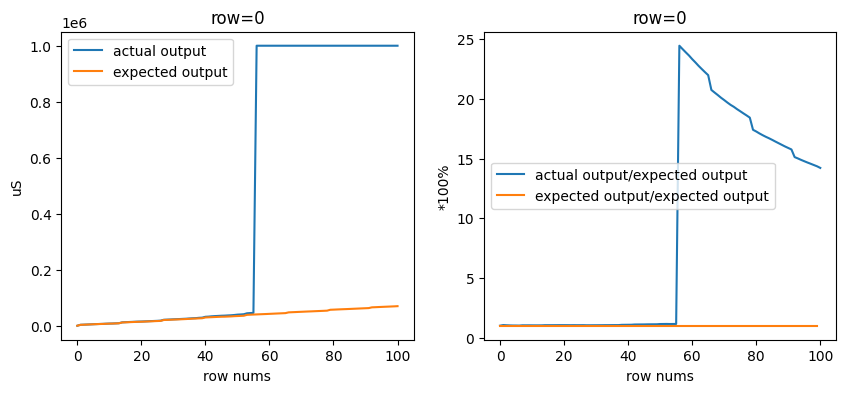

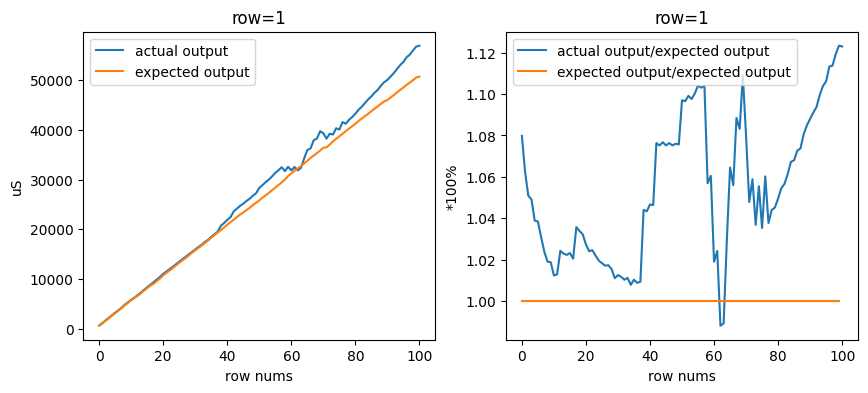

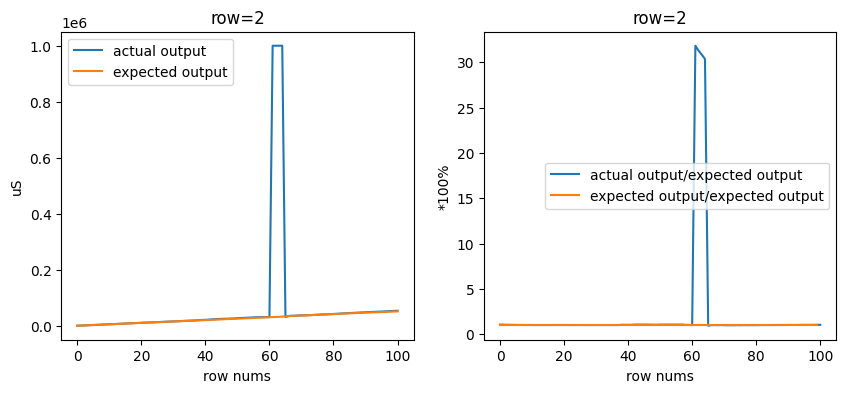

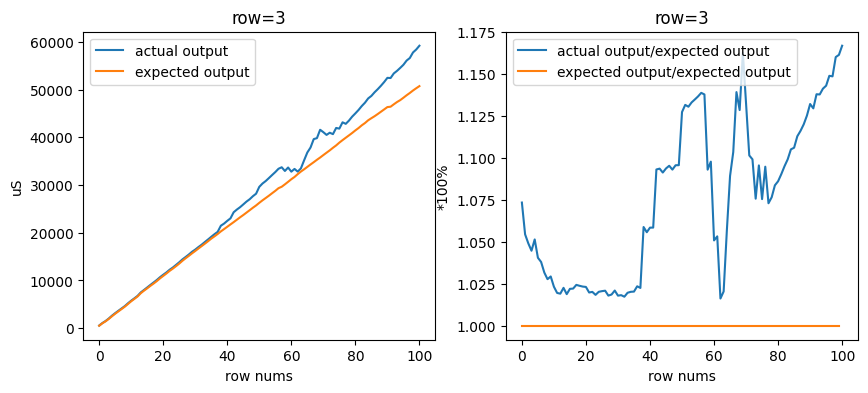

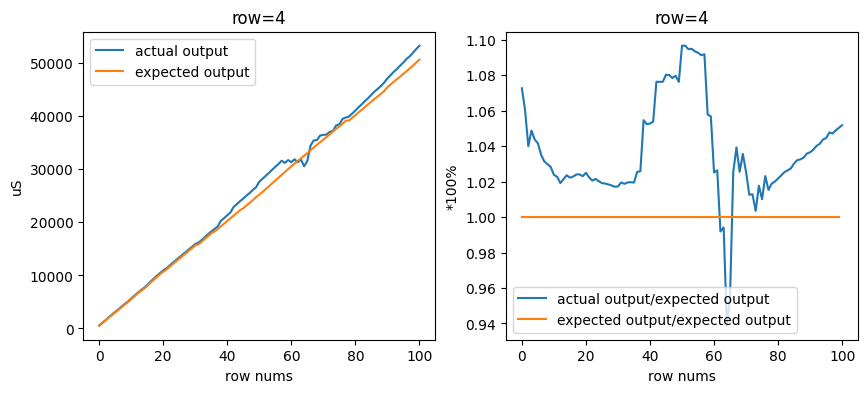

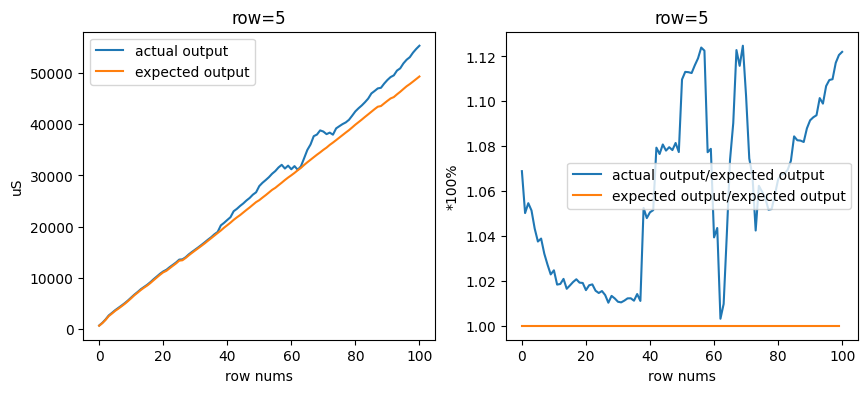

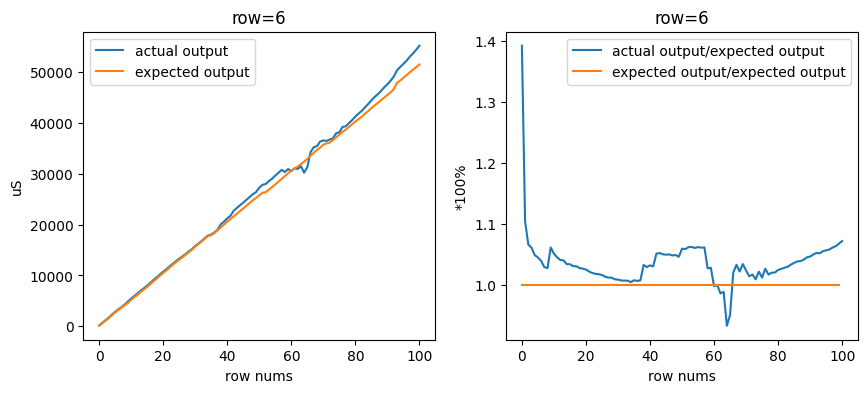

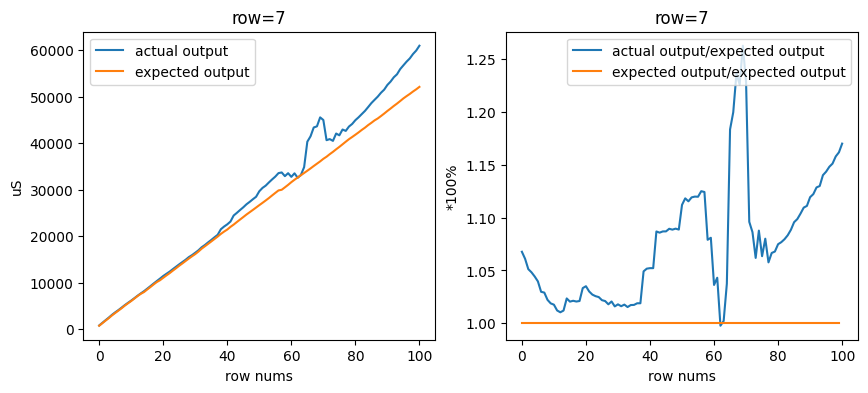

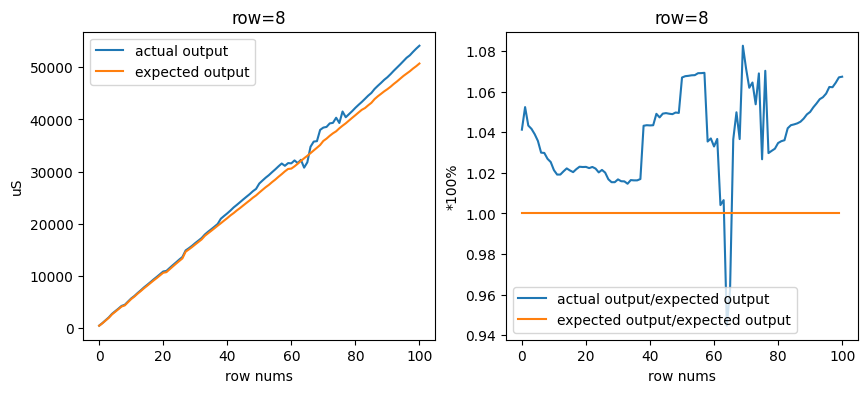

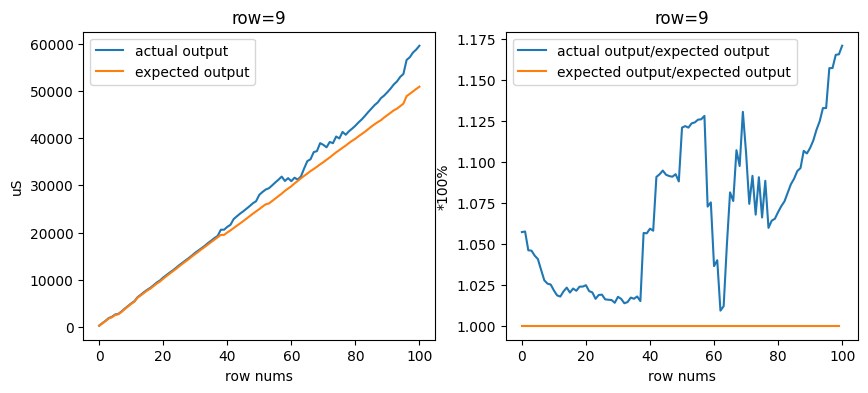

In [329]:
startpos,endpos = 0,101
for num in range(10):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(real_cond_res[startpos:endpos,num].flatten(),label = "actual output")
    plt.plot(expected_res[startpos:endpos,num].flatten(),label = "expected output")
    plt.title(f"row={row_index[num]}")
    plt.ylabel("uS")
    plt.xlabel("row nums")
    plt.legend()
    # plt.show()
    plt.subplot(1,2,2)
    plt.plot(real_cond_res[startpos:endpos,num].flatten()/expected_res[startpos:endpos,num].flatten(),label = "actual output/expected output")
    plt.plot(np.ones(endpos-startpos-1),label = "expected output/expected output")
    plt.title(f"row={row_index[num]}")
    plt.ylabel("*100%")
    plt.xlabel("row nums")
    plt.legend()
    plt.show()

In [ ]:
chip.compensation.initop(root_path)
# chip.compensation.row_offset=0
# chip.compensation.row_value=0
# chip.compensation.row_r_out=0
# 10列，两路TIA并行
row_index = [i for i in range(256)]
# 存储数据
real_res = np.zeros((256,256))
real_cond_res = np.zeros((256,256))
expected_res = np.zeros((256,256))

chip.setting.tia_map = [j for j in range(8) for i in range(2)]

for i in range(101):
    col_index = [j for j in range(i+1)]

    _,cond,r = chip.read4(crossbar=np.ones((256,256)),row_index=row_index,col_index=col_index,read_voltage=0.1,tg=5,gain=3,sub_base=True,from_row=False,split_type=4,row_type=0,col_type=0)
    cond = chip.compensation.compensation_forward(col_index,r,from_row=False,return_type=0,parallel=8)
    pos = np.ix_(row_index,col_index)
    expected_res[i,:]=np.sum(c_expected_from_col[pos],axis=1).flatten()
    real_res[i,:]=r
    real_cond_res[i,:] = cond[row_index]

In [ ]:
startpos,endpos = 0,101
for num in range(9):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(real_cond_res[startpos:endpos,num].flatten(),label = "actual output")
    plt.plot(expected_res[startpos:endpos,num].flatten(),label = "expected output")
    plt.title(f"col={col_index[num]}")
    plt.ylabel("uS")
    plt.xlabel("row nums")
    plt.legend()
    # plt.show()
    plt.subplot(1,2,2)
    plt.plot(real_cond_res[startpos:endpos,num].flatten()/expected_res[startpos:endpos,num].flatten(),label = "actual output/expected output")
    plt.plot(np.ones(endpos-startpos-1),label = "expected output/expected output")
    plt.title(f"col={col_index[num]}")
    plt.ylabel("*100%")
    plt.xlabel("row nums")
    plt.legend()
    plt.show()

# 2. 计算补偿参数

## 2.1 从行给信号列出

In [ ]:
r_wire = chip.compensation.r_wire
r_out_col = chip.compensation.col_r_out


In [ ]:
def compensation_offset_from_row(x,offset,col):
    """
        计算补偿
    """
    rows = len(x)
    ans = np.zeros(rows)
    for i in range(rows):
        sum_rw = (255-i)*r_wire if col%2==0 else 0
        r_out = r_out_col[col]
        real_r = real_res[i,col]*1e3 -r_out -sum_rw + offset
        ans[i]=1/real_r*1e6
    return ans/expected_res[:rows,col]

cnt = 31
ans = np.zeros(256)

for i in range(256):
    params, covariance = curve_fit(lambda x,offset:compensation_offset_from_row(x,offset,i),[i for i in range(cnt)], np.ones(cnt), p0=[0],bounds=([-15], [15]))
    ans[i] = params[0]

In [ ]:
np.save(root_path + "col_offset_parallel.npy",ans)
print(ans)

In [ ]:
offset_col = np.load(root_path + "col_offset_parallel.npy")
def compensation_value_from_row(x,value,col):
    """
        计算补偿
    """
    rows = len(x)
    ans = np.zeros(rows)
    for i in range(rows):
        sum_rw = (255-i)*r_wire if col%2==0 else 0
        r_out = r_out_col[col]
        real_r = real_res[i,col]*1e3 -r_out -sum_rw + offset_col[col]  - r_wire*(i**value)
        ans[i]=1/real_r*1e6
    return ans/expected_res[:rows,col]

cnt = 101
ans = np.zeros(256)

for i in range(256):
    params, covariance = curve_fit(lambda x,value:compensation_value_from_row(x,value,i),[i for i in range(cnt)], np.ones(cnt), p0=[0.5],bounds=([0], [1]))
    ans[i] = params[0]

In [ ]:
np.save(root_path + "col_value_parallel_16.npy",ans)
print(ans)

## 2.1 从列给信号

In [291]:
chip.compensation.initop(root_path)
r_wire = chip.compensation.r_wire
r_out_row = chip.compensation.row_r_out

print(r_out_row)

[19.13085938 21.76757812 21.74804688 22.04101562 21.86523438 22.33398438
 22.74414062 22.56835938 22.86132812 22.84179688 22.84179688 23.09570312
 23.23242188 23.38867188 22.70507812 23.58398438 21.78710938 21.63085938
 21.82617188 21.92382812 21.90429688 22.19726562 21.31835938 22.49023438
 22.60742188 22.70507812 22.74414062 22.97851562 23.21289062 23.25195312
 23.27148438 23.56445312 20.96679688 21.68945312 21.27929688 22.02148438
 21.08398438 22.31445312 21.63085938 22.58789062 21.96289062 22.86132812
 22.11914062 23.07617188 22.21679688 23.31054688 22.84179688 23.64257812
 21.29882812 21.61132812 21.02539062 21.86523438 21.82617188 22.08007812
 21.90429688 22.43164062 22.37304688 22.64648438 22.49023438 22.91992188
 22.52929688 23.17382812 23.15429688 23.50585938 20.73242188 21.22070312
 20.71289062 21.53320312 20.81054688 21.80664062 21.08398438 21.31835938
 21.55273438 22.35351562 22.29492188 22.66601562 21.88476562 22.90039062
 22.60742188 23.11523438 20.61523438 21.12304688 20

In [297]:
def compensation_offset_from_col(x,offset,row):
    """
        计算补偿
    """
    rows = len(x)
    ans = np.zeros(rows)
    for i in range(rows):
        sum_rw = (255-i)*r_wire if row%2==1 else 0
        r_out = r_out_row[row]
        real_r = real_res[i,row]*1e3 -r_out -sum_rw + offset
        ans[i]=1/real_r*1e6
    return ans/expected_res[:rows,row]

cnt = 31
ans = np.zeros(256)

for i in range(256):
    params, covariance = curve_fit(lambda x,offset:compensation_offset_from_col(x,offset,i),[i for i in range(cnt)], np.ones(cnt), p0=[0],bounds=([-10], [10]))
    ans[i] = params[0]

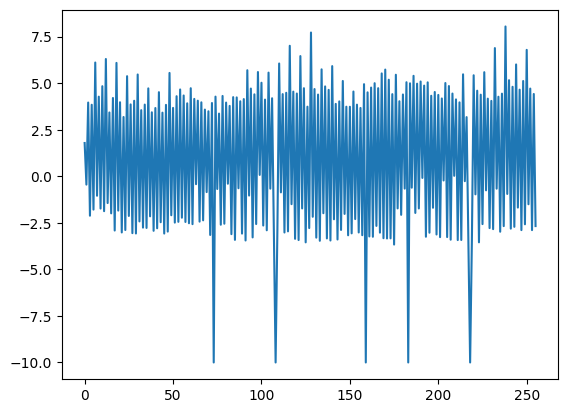

In [298]:
plt.plot(ans)
plt.show()
np.save(root_path + "row_offset.npy",ans)

In [303]:
offset_row = np.load(root_path + "row_offset.npy")
def compensation_value_from_col(x,value,row):
    """
        计算补偿
    """
    rows = len(x)
    ans = np.zeros(rows)
    for i in range(rows):
        sum_rw = (255-i)*r_wire if row%2==1 else 0
        r_out = r_out_row[row]
        real_r = real_res[i,row]*1e3 -r_out -sum_rw + offset_row[row]  - r_wire*(i**value)
        ans[i]=1/real_r*1e6
    return ans/expected_res[:rows,row]

cnt = 101
ans = np.zeros(256)
ans2 = np.zeros(256)
for i in range(256):
    params, covariance = curve_fit(lambda x,value:compensation_value_from_col(x,value,i),[i for i in range(cnt)], np.ones(cnt), p0=[0.5],bounds=([0], [1]))
    ans[i] = params[0]

In [305]:
np.save(root_path + "row_value_parallel.npy",ans)
print(ans)

[3.27080284e-18 8.41505527e-01 8.80836179e-01 7.50529078e-01
 8.71325745e-01 7.65641719e-01 9.26195582e-01 8.00863796e-01
 8.63173174e-01 7.61484488e-01 9.00416060e-01 6.99764756e-01
 9.50229734e-01 7.82429497e-01 8.70995620e-01 7.73316398e-01
 8.65444261e-01 7.19901481e-01 9.44159939e-01 7.87751021e-01
 8.78639762e-01 7.14243453e-01 8.53401736e-01 7.00203286e-01
 9.09962527e-01 7.80851493e-01 8.74410630e-01 6.82323429e-01
 8.70283712e-01 7.11590944e-01 9.21111048e-01 7.44710966e-01
 8.77648921e-01 7.22204887e-01 8.80620498e-01 7.10794721e-01
 9.26277025e-01 7.47654893e-01 8.71351690e-01 7.10770225e-01
 8.80603994e-01 7.12989157e-01 9.18074372e-01 7.35892937e-01
 8.83253265e-01 7.09182174e-01 8.86614925e-01 7.03227284e-01
 9.20536740e-01 6.80984074e-01 8.80643344e-01 7.15439449e-01
 8.80268454e-01 7.27381580e-01 8.94479152e-01 7.27501443e-01
 8.85244525e-01 7.26968122e-01 8.68175245e-01 7.33383020e-01
 9.03926280e-01 7.22725831e-01 8.65358118e-01 8.35597259e-01
 8.80815850e-01 7.407631

In [ ]:

def compensation_value_from_col(x,offset,value,row):
    """
        计算补偿
    """
    rows = len(x)
    ans = np.zeros(rows)
    for i in range(rows):
        sum_rw = (255-i)*r_wire if row%2==1 else 0
        r_out = r_out_row[row]
        real_r = real_res[i,row]*1e3 -r_out -sum_rw + offset - r_wire*(i**value)
        ans[i]=1/real_r*1e6
    return ans/expected_res[:rows,row]

cnt = 81
ans_offset = np.zeros(256)
ans_value = np.zeros(256)
for i in range(256):
    params, covariance = curve_fit(lambda x,offset,value:compensation_value_from_col(x,offset,value,i),[i for i in range(cnt)], np.ones(cnt), p0=[0,0.5],bounds=([-100,0], [100,10]))
    ans_offset[i] = params[0]
    ans_value[i] = params[1]

In [ ]:
print(ans_offset)
plt.plot(ans_offset)
plt.show()
plt.plot(ans_value)
print(ans_value)
plt.show()

In [ ]:
np.save(root_path + "row_value_parallel.npy",ans_value)
np.save(root_path + "row_offset.npy",ans_offset)
# print(ans)

# 3.补偿结果

### 3.1 从行给信号列出